In [ ]:
import numpy as np
import pandas as pd
import sklearn
import seaborn as sbs

In [ ]:
df = pd.read_csv('loan_data.csv')

In [ ]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [ ]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


Пропущенные значения в датасете отсутствуют

In [ ]:
print(df.duplicated().sum())

0


Дубликатов нет

In [ ]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [ ]:
# выведем некоторую статистику по loan_status
df.groupby('loan_status').describe()

person_age                                                      \
                 count       mean       std   min   25%   50%   75%    max   
loan_status                                                                  
0              35000.0  27.833571  6.073367  20.0  24.0  26.0  30.0  144.0   
1              10000.0  27.521300  5.939063  20.0  23.0  26.0  30.0   70.0   

            person_income                ... cb_person_cred_hist_length        \
                    count          mean  ...                        75%   max   
loan_status                              ...                                    
0                 35000.0  86157.040743  ...                        8.0  30.0   
1                 10000.0  59886.096900  ...                        8.0  30.0   

            credit_score                                                     \
                   count        mean        std    min    25%    50%    75%   
loan_status                                                                   
0                35000.0  632.814914  50.475294  390.0  602.0  640.0  670.0   
1                10000.0  631.887200  50.293485  431.0  601.0  639.0  669.0   

                    
               max  
loan_status         
0            850.0  
1            767.0  

[2 rows x 64 columns]

<Axes: >

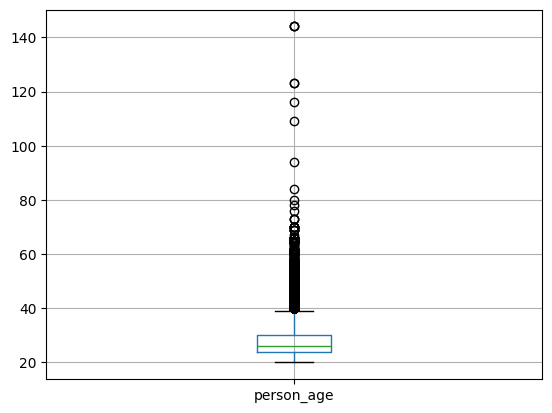

In [ ]:
df.boxplot(column='person_age')

Удалим выбросы по возрасту, оставив только наблюдения в интервале между 0.1-м и 99.9-м перцентилями

In [ ]:
lower = df['person_age'].quantile(0.0001)
upper = df['person_age'].quantile(0.9999)
df_new = df[(df['person_age'] >= lower) & (df['person_age'] <= upper)]
df_new.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44995.000000,4.499500e+04,44995.000000,44995.000000,44995.000000,44995.00000,44995.000000,44995.000000,44995.000000
mean,27.752195,8.015163e+04,5.398244,9582.973441,11.006508,0.13973,5.867319,632.590932,0.222247
std,5.936603,7.307509e+04,5.953239,6314.740894,2.978933,0.08721,3.878769,50.408147,0.415761
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.00000,2.000000,390.000000,0.000000
25%,24.000000,4.719650e+04,1.000000,5000.000000,8.590000,0.07000,3.000000,601.000000,0.000000
50%,26.000000,6.704600e+04,4.000000,8000.000000,11.010000,0.12000,4.000000,640.000000,0.000000
75%,30.000000,9.578250e+04,8.000000,12236.000000,12.990000,0.19000,8.000000,670.000000,0.000000
max,116.000000,5.556399e+06,93.000000,35000.000000,20.000000,0.66000,30.000000,792.000000,1.000000


Разделим выборку на train/test для обучения

In [ ]:
from sklearn.model_selection import train_test_split

y = df_new['loan_status']
X = df_new.drop(columns=['loan_status'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def make_num_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler()
    )

def make_cat_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown='ignore')
    )

Разделим признаки на категориальные и метрические и преобразуем их согласно функциям выше. Для некоторых моделей ниже критично наличие стандартизации, поэтому сделаем её

In [ ]:
from sklearn.compose import ColumnTransformer

numeric_columns = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', make_num_pipeline(), numeric_columns),
        ('cat', make_cat_pipeline(), categorical_columns)
    ]
)

#### Перед построением моделей важно упомянуть, что т к мы решаем задачу кредитного скоринга, то при всём многообразии метрик (accuracy, F1-score, precision,  recall, log-loss...) будем использовать ROC-AUC, т к она устойчива к дисбалансу классов и позволит в дальнейшем исследовании сравнить различные модели

## Построим первую модель - модель логистической регрессии

Для начала создадим валидационную выборку для того, чтобы на ней подобрать порог, по которому будем определять к какому классу принадлежать каждая вероятность

In [ ]:
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train, y_train,
    test_size = 0.2,
    stratify=y_train,
    random_state=42)

При построении воспользуемся $L_2$-регуляризаций

In [ ]:
from sklearn.linear_model import LogisticRegression

model_logistic_regression = make_pipeline(
    preprocess,
    LogisticRegression(penalty='l2')
)

model_logistic_regression.fit(X_train_new, y_train_new)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_exp',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length',
                                                   'credit_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_gender',
                                                   'person_education',
                                                   'person_home_ownership',
                                                   'loan_intent',
                                                   'previous_loan_defaults_on_file'])])),
                ('logisticregression', LogisticRegression())])

Посчитаем порог на валидации. Для этого, как обычно это происходит в реальности, зададим max_bad_rate - максимальную долю дефолтов среди тех, кого одобрили, который допустим для нас и в зависимости от этого посчитаем пороговое значение

In [ ]:
def find_threshold(y_val, y_proba_val, max_bad_rate=0.05):
    sorted_indices = np.argsort(y_proba_val)
    sorted_probs = y_proba_val[sorted_indices]
    sorted_labels = y_val.iloc[sorted_indices]

    best_threshold = 0
    max_approval_rate = 0
    actual_bad_rate = 0

    for i in range(1, len(sorted_probs)):
        threshold = sorted_probs[i]
        approved_mask = sorted_probs >= threshold
        approved_labels = sorted_labels[approved_mask]

        if len(approved_labels) == 0:
            continue

        bad_rate = (approved_labels == 0).mean()

        if bad_rate <= max_bad_rate:
            approval_rate = len(approved_labels) / len(sorted_labels)
            if approval_rate > max_approval_rate:
                max_approval_rate = approval_rate
                best_threshold = threshold
                actual_bad_rate = bad_rate

    return best_threshold, max_approval_rate, actual_bad_rate

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_auc_score

y_proba_val = model_logistic_regression.predict_proba(X_val)[:, 1]
threshold, approval_rate, bad_rate = find_threshold(y_val, y_proba_val)

print(f"Оптимальный порог: {threshold:.2f}")
print(f"Доля одобрений: {approval_rate:.2%}")
print(f"Bad rate: {bad_rate:.2%}, выставленный лимит - 5%")

Оптимальный порог: 0.86
Доля одобрений: 8.40%
Bad rate: 4.96%, выставленный лимит - 5%


Посчитаем результат на тестовых данных

In [ ]:
y_proba_test = model_logistic_regression.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)

approved = y_pred_test == 0
approval_rate_test = approved.mean()
bad_rate_test = y_test[approved].mean()

print(f"Доля одобрений: {approval_rate_test:.1%}")
print(f"Уровень дефолтов среди одобренных: {bad_rate_test:.2%}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_test):.4f}")

Доля одобрений: 92.0%
Уровень дефолтов среди одобренных: 15.96%
ROC-AUC: 0.9526


## Построим модель SVM

Для SVM попробуем взять две разных ядровых функции:
в начале попробуем linear, а далее rbf

#### SVM с линейной ядровой функцией

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.svm import SVC

svm_linear = make_pipeline(
    preprocess,
    SVC(kernel='linear', probability=False, random_state=42)
)

search_linear = RandomizedSearchCV(
    svm_linear,
    param_distributions={'svc__C': loguniform(1e-3, 1e3)},
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search_linear.fit(X_train, y_train)

print("Лучшие гиперпараметры:", search_linear.best_params_)
print("ROC-AUC на кросс-валидации:", search_linear.best_score_)

Посчитаем на test ROC-AUC

In [ ]:
best_svm_linear = search_linear.best_estimator_
test_roc_auc = roc_auc_score(y_test, best_svm_linear.decision_function(X_test))

print(f"Test ROC-AUC: {test_roc_auc:.4f}")

#### SVM с ядровой функцией rbf

In [ ]:
svm_rbf = make_pipeline(
    preprocess,
    SVC(kernel='rbf', probability=False, random_state=42)
)

search_rbf = RandomizedSearchCV(
    svm_rbf,
    param_distributions={
        'svc__C': loguniform(1e-3, 1e3),
        'svc__gamma': loguniform(1e-4, 1e-1)
    },
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search_rbf.fit(X_train, y_train)

print("Лучшие гиперпараметры:", search_rbf.best_params_)
print("ROC-AUC на кросс-валидации:", search_rbf.best_score_)

Посчитаем на test ROC-AUC

In [ ]:
best_svm_rbf = search_rbf.best_estimator_
test_roc_auc = roc_auc_score(y_test, best_svm_rbf.decision_function(X_test))

print(f"Test ROC-AUC: {test_roc_auc:.4f}")